# Teen Mental Health and Social Media Impact Analysis

This notebook explores the relationship between social media usage and mental health in teenagers, following the plan outlined in `plans.md`.

## Phase 1: Environment Setup & Data Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    import xgboost as xgb
except ImportError:
    print("XGBoost not found. Please install it using 'pip install xgboost'")

try:
    import shap
except ImportError:
    print("SHAP not found. Please install it using 'pip install shap'")

warnings.filterwarnings('ignore')
%matplotlib inline

# Load the dataset
try:
    df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("Dataset file not found. Please ensure 'Teen_Mental_Health_Dataset.csv' is in the same directory.")

SHAP not found. Please install it using 'pip install shap'
Dataset Shape: (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## Phase 2: Exploratory Data Analysis (EDA)

Missing Values:
 age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


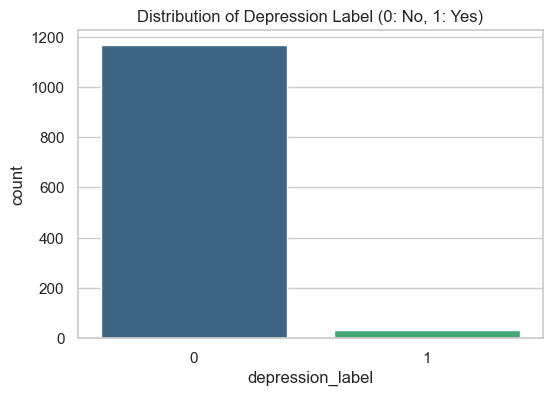

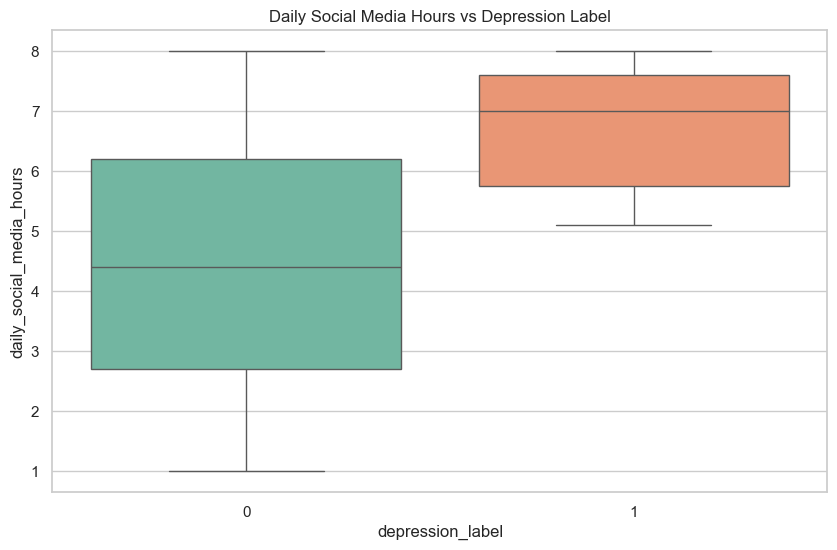

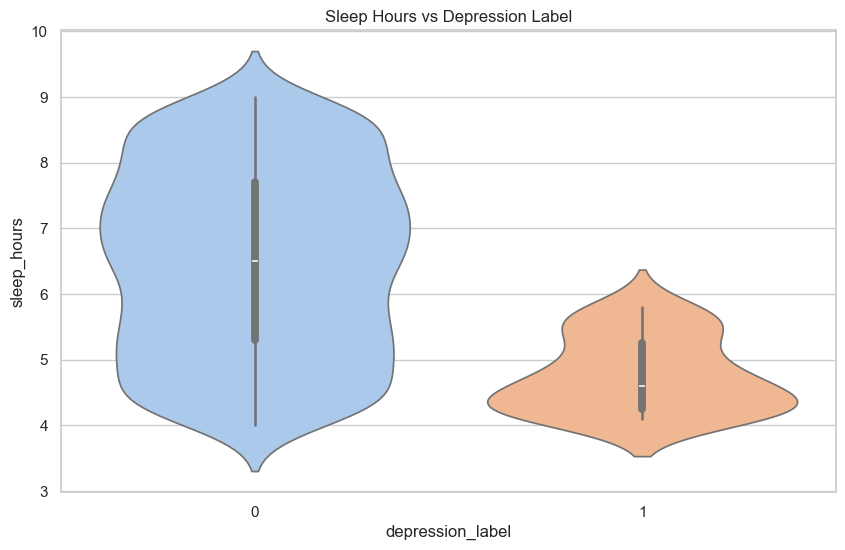

In [14]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Set visual style
sns.set(style="whitegrid")

# 1. Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='depression_label', data=df, palette='viridis')
plt.title('Distribution of Depression Label (0: No, 1: Yes)')
plt.show()

# 2. Social Media Hours vs Depression
plt.figure(figsize=(10, 6))
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df, palette='Set2')
plt.title('Daily Social Media Hours vs Depression Label')
plt.show()

# 3. Sleep Hours vs Depression
plt.figure(figsize=(10, 6))
sns.violinplot(x='depression_label', y='sleep_hours', data=df, palette='pastel')
plt.title('Sleep Hours vs Depression Label')
plt.show()

## Phase 3: Data Preprocessing

In [15]:
# Encoding categorical variables
le = LabelEncoder()

# List of categorical columns
categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']

# Create a copy for modeling
df_model = df.copy()

print("Encoding mapping:")
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Encoding mapping:
gender: {'female': 0, 'male': 1}
platform_usage: {'Both': 0, 'Instagram': 1, 'TikTok': 2}
social_interaction_level: {'high': 0, 'low': 1, 'medium': 2}


## Phase 4: Advanced Model Training & Tuning

In [16]:
# Define Features and Target
X = df_model.drop('depression_label', axis=1)
y = df_model['depression_label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 4.1 Hyperparameter Tuning (Random Forest) ---")
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42), 
                               param_distributions=param_dist, 
                               n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

rf_random.fit(X_train, y_train)
best_rf = rf_random.best_estimator_
print(f"Best Parameters: {rf_random.best_params_}")

print("\n--- 4.2 XGBoost Model Training ---")
try:
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
except NameError:
    print("XGBoost training skipped as library is missing.")

--- 4.1 Hyperparameter Tuning (Random Forest) ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}

--- 4.2 XGBoost Model Training ---
XGBoost Accuracy: 1.0000


## Phase 5: Deep Interpretability & Tipping Point Analysis

SHAP Analysis failed: No module named 'shap'. Ensure 'shap' is installed.


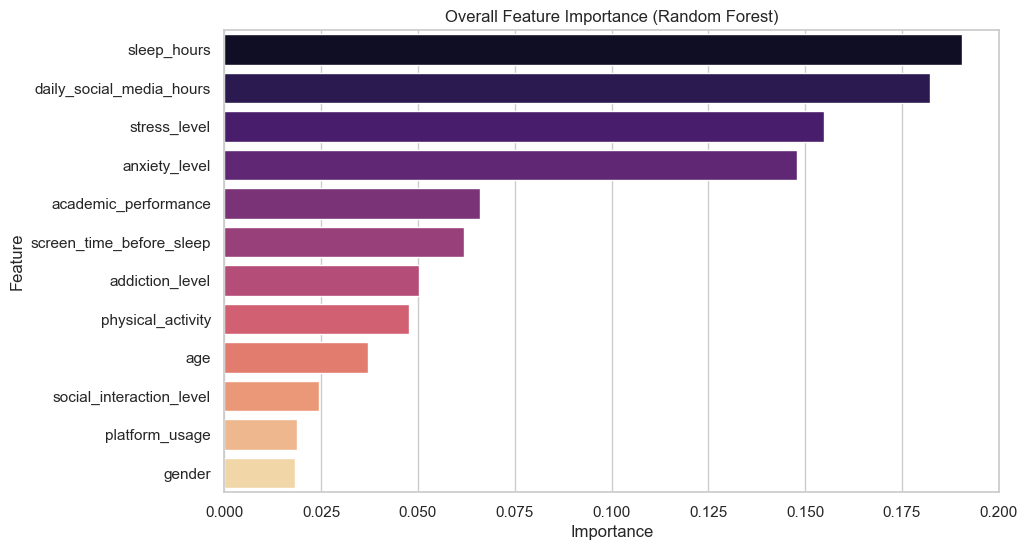

In [17]:
# 5.1 SHAP Deep Dive
try:
    import shap
    print("Generating SHAP summary plot (Individual Feature Impacts)...")
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_test)
    
    # Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1], X_test)
    
    # Dependence Plot for Social Media Hours
    print("\nAnalyzing the 'Tipping Point' for Social Media Usage...")
    shap.dependence_plot("daily_social_media_hours", shap_values[1], X_test)
    
except Exception as e:
    print(f"SHAP Analysis failed: {e}. Ensure 'shap' is installed.")

# 5.2 Traditional Feature Importance
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Overall Feature Importance (Random Forest)')
plt.show()

## Phase 6: Practical Risk Assessment Calculator

In [18]:
def assess_depression_risk(age, gender, daily_hours, platform, sleep, screen_before, academic, physical, social, stress, anxiety, addiction):
    """
    Uses the trained best_rf model to assess risk based on behavioral metrics.
    """
    gender_map = {'female': 0, 'male': 1}
    platform_map = {'Both': 0, 'Instagram': 1, 'TikTok': 2}
    social_map = {'high': 0, 'low': 1, 'medium': 2}
    
    input_data = pd.DataFrame([{
        'age': age,
        'gender': gender_map.get(gender, 0),
        'daily_social_media_hours': daily_hours,
        'platform_usage': platform_map.get(platform, 0),
        'sleep_hours': sleep,
        'screen_time_before_sleep': screen_before,
        'academic_performance': academic,
        'physical_activity': physical,
        'social_interaction_level': social_map.get(social, 2),
        'stress_level': stress,
        'anxiety_level': anxiety,
        'addiction_level': addiction
    }])
    
    input_data = input_data[X.columns]
    prediction = best_rf.predict(input_data)[0]
    probability = best_rf.predict_proba(input_data)[0][1]
    
    print("="*40)
    print("   TEEN MENTAL HEALTH RISK ASSESSMENT   ")
    print("="*40)
    print(f"Predictive Status: {'⚠️ HIGH RISK' if prediction == 1 else '✅ LOW RISK'}")
    print(f"Confidence Level:  {probability:.1%}")
    print("-"*40)
    
    if probability > 0.75:
        print("ACTION: Immediate clinical screening is highly recommended.")
    elif probability > 0.45:
        print("ACTION: Moderate risk detected. Suggest reduction in screen time.")
    else:
        print("ACTION: No significant risk indicators detected.")
    print("="*40)

print("Function 'assess_depression_risk' is updated and ready!")

Function 'assess_depression_risk' is updated and ready!


In [19]:
# Test Case
assess_depression_risk(
    age=17, gender='female', daily_hours=9.5, platform='Both', 
    sleep=4.0, screen_before=4.0, academic=1.8, physical=0.1, 
    social='low', stress=10, anxiety=9, addiction=10
)

   TEEN MENTAL HEALTH RISK ASSESSMENT   
Predictive Status: ⚠️ HIGH RISK
Confidence Level:  57.5%
----------------------------------------
ACTION: Moderate risk detected. Suggest reduction in screen time.
